In [2]:
import pandas as pd

In [7]:
df = pd.read_csv('./20250925_083347.csv')
df

,email,title_id,title,COUNT(key_id)
0,dog-foxx@mail.ru,2809.0,Masky,92
1,dasoneerett@gmail.com,2802.0,Fly O'Clock,76
2,dasoneerett@gmail.com,2814.0,Risky Rescue,76
3,dasoneerett@gmail.com,2797.0,8infinity,76
4,dasoneerett@gmail.com,12013.0,Pongo,68
...,...,...,...,...
4615,zverdj2@gmail.com,34267.0,No Man's Sky,1
4616,zvezdinkir1982@ya.ru,41468.0,Карта оплаты Sony PlayStation: пополнение коше...,1
4617,zvndach@gmail.com,38146.0,Lost in Tropics,1
4618,gyfimcev@gmail.con,41468.0,Карта оплаты Sony PlayStation: пополнение коше...,0


In [11]:
print(f'Кол-во уникальных email: {len(df['email'].unique())}')
print(f'Кол-во уникальных title_id: {len(df['title_id'].unique())}')

Кол-во уникальных email: 2363
Кол-во уникальных title_id: 1264


In [15]:
user_item_matrix = df.pivot_table(index='email', columns='title', values='COUNT(key_id)', fill_value=0)

In [16]:
user_item_matrix.shape

(2363, 1242)

In [17]:
user_item_matrix

title,10 Second Ninja X,11-11 Memories Retold,112 Operator,12 is Better Than 6,15 Days,3D Chess,3D MiniGolf,3D Pool,"7,62 High Calibre + 7,62 Hard Life","7,62 High Calibre, 7,62 Hard Life, Brigade E5: New Jagged Union Pack",...,Карта оплаты Sony PlayStation: пополнение кошелька на 4000 ₺ (Турция),Карта оплаты Sony PlayStation: пополнение кошелька на 50 zl (Польша),Карта оплаты Sony PlayStation: пополнение кошелька на 500 ₺ (Турция),Карта оплаты Sony PlayStation: пополнение кошелька на 5000 ₺ (Турция),Карта оплаты Sony PlayStation: пополнение кошелька на 650 zl (Польша),Карта оплаты Sony PlayStation: пополнение кошелька на 750 ₺ (Турция),Карта оплаты Sony PlayStation: пополнение кошелька на 900 zl (Польша),Пополнение кошелька Playstation Store Польша 100zl (PSN),Пополнение кошелька Playstation Store Польша 500zl (PSN),Пополнение кошелька Playstation Store Польша 50zl (PSN)
email,,,,,,,,,,,,,,,,,,,,,
0n3g001@gmail.com,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10596fil@gmail.com,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11111mixa11111@gmail.com,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1134hell@gmail.com,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1150vova1150@mail.ru,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zvezdinkir1982@ya.ru,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
zvndach@gmail.com,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
zvuk104@gmail.com,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
# поиска похожих векторов
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_item_matrix)
user_similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)

In [36]:
user_similarity_df

email,0n3g001@gmail.com,10596fil@gmail.com,11111mixa11111@gmail.com,1134hell@gmail.com,1150vova1150@mail.ru,11peen11@gmail.com,1224192@mail.ru,123denisvalko123@gmail.com,19961996dendenis@mail.ru,1999semen@mail.ru,...,zubko2706@gmail.com,zum139@mail.ru,zurov1992@mail.ru,zv1488smerthohlam@gmail.com,zverdj2@gmail.com,zvezdinkir1982@ya.ru,zvndach@gmail.com,zvuk104@gmail.com,zxcbobr7@gmail.com,zzinch@mail.ru
email,,,,,,,,,,,,,,,,,,,,,
0n3g001@gmail.com,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
10596fil@gmail.com,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.408248,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
11111mixa11111@gmail.com,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1134hell@gmail.com,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1150vova1150@mail.ru,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.707107,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zvezdinkir1982@ya.ru,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.0
zvndach@gmail.com,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.0
zvuk104@gmail.com,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.0,0.0,0.0


In [52]:
users = ['babanoves@mail.ru', 'iskrit94@gmail.com', 'artem00saraev@mail.ru', 'tsvaygerdta@mail.ru', 'progamerhitewoolf@rambler.ru']

In [51]:
def get_purchased_by_users(users):
    purchased = {}
    for user in users:
        s = user_item_matrix.loc[user]
        for title in s[s > 0].index:
            if title not in purchased.keys(): 
                purchased[title] = 0
            purchased[title] += 1
    return purchased

get_purchased_by_users(users)

{"V Rising - Dracula's Relics Pack": 3,
 'V Rising - Eternal Dominance Pack': 2,
 "V Rising - Founder's Pack: Eldest Bloodline": 4,
 'V Rising - Legacy of Castlevania Premium Pack': 3,
 'V Rising - Sinister Evolution Pack': 4,
 'DOOM: The Dark Ages - Premium Edition': 1,
 'V Rising': 1,
 "Ghost of Tsushima DIRECTOR'S CUT": 1,
 'Against the Storm': 1,
 'Against the Storm - Keepers of the Stone': 1,
 'Against the Storm - Nightwatchers': 1}

In [81]:
def get_recommendations(user_id, user_item_matrix, user_similarity_df, top_n=5, neighbor_count=5, neighbor_thresh=0.3, debug=False):
    if user_id not in user_item_matrix.index:
        return []

    if debug is True:
        print('Игры пользователя')
        print(get_purchased_by_users([user_id]), end='\n\n')
    
    # Найти похожих пользователей
    similar_users_df = user_similarity_df[user_id].drop(user_id).sort_values(ascending=False).head(neighbor_count)
    similar_users = similar_users_df[similar_users_df > neighbor_thresh].index

    if debug is True:
        print('Топ ближайших пользователей')
        print(similar_users_df, end='\n\n')
        print('Номенклатура игр пользователей из топа')
        print(get_purchased_by_users(similar_users), end='\n\n')

    # Суммировать покупки по похожим
    similar_users_purchases = user_item_matrix.loc[similar_users].sum()
    
    # Убрать уже купленные этим пользователем
    user_purchases = user_item_matrix.loc[user_id]
    selected = similar_users_purchases[user_purchases == 0].sort_values(ascending=False).head(top_n)

    # Откинем те, которые никто не покупал
    recommended = selected[selected > 0]

    if debug is True:
        print('Выбранные для покупки')
        print(recommended)

    return recommended.index.tolist()


## Посмотрим как это работает

In [61]:
# пользователи с широкой номенклатурой
df['email'].value_counts()[50:75]

email
kobzev5.22@yandex.ru                9
sml45@mail.ru                       9
conjurer@inbox.ru                   9
x0mka90@mail.ru                     9
angera13@mail.ru                    9
leolatis@gmail.com                  9
zoltaromfg@inbox.ru                 8
ult.k@mail.ru                       8
dimane1999@gmail.com                8
vladgaevskij09876@gmail.com         8
1igor97@mail.ru                     8
gabdullinnadim@gmail.com            8
anton23.03@yandex.ru                8
davletsinvladislav2033@gmail.com    8
soiamglad@yandex.ru                 8
otss01@mail.ru                      8
eejeneee@gmail.com                  8
e.orishaka@gmail.com                7
d.sokerin@gmail.com                 7
tmnedu@yandex.ru                    7
hippocuaron@yandex.ru               7
m-lim2on@yandex.ru                  7
cordiant69@yandex.ru                7
yurfakemail@inbox.ru                7
zlatovlass@gmail.com                7
Name: count, dtype: int64

In [80]:
get_recommendations('soulunius@yandex.ru', user_item_matrix, user_similarity_df, debug=True)

Игры пользователя
{'Against the Storm - Keepers of the Stone': 1, 'Against the Storm - Nightwatchers': 1, 'The Slormancer': 1, 'Tinkerlands': 1, "V Rising - Dracula's Relics Pack": 1, 'V Rising - Eternal Dominance Pack': 1, "V Rising - Founder's Pack: Eldest Bloodline": 1, 'V Rising - Legacy of Castlevania Premium Pack': 1, 'V Rising - Sinister Evolution Pack': 1}

Топ ближайших пользователей
email
babanoves@mail.ru               0.745356
iskrit94@gmail.com              0.666667
artem00saraev@mail.ru           0.629941
tsvaygerdta@mail.ru             0.384900
progamerhitewoolf@rambler.ru    0.384900
Name: soulunius@yandex.ru, dtype: float64

Номенклатура игр пользователей из топа
{"V Rising - Dracula's Relics Pack": 3, 'V Rising - Eternal Dominance Pack': 2, "V Rising - Founder's Pack: Eldest Bloodline": 4, 'V Rising - Legacy of Castlevania Premium Pack': 3, 'V Rising - Sinister Evolution Pack': 4, 'DOOM: The Dark Ages - Premium Edition': 1, 'V Rising': 1, "Ghost of Tsushima DIRECTOR'S

['DOOM: The Dark Ages - Premium Edition',
 "Ghost of Tsushima DIRECTOR'S CUT",
 'Against the Storm',
 'V Rising']

In [73]:
get_recommendations('zlatovlass@gmail.com', user_item_matrix, user_similarity_df, debug=True)

Игры пользователя
{'9 Kings': 1, 'DOOM: The Dark Ages - Premium Edition': 1, 'Die in the Dungeon': 1, 'ELDEN RING NIGHTREIGN': 1, 'Odinfall': 1, 'Stellar Blade™ Complete Edition': 1, 'Tales of Seikyu': 1}

Топ ближайших пользователей
email
kamimidzu@gmail.com        0.436436
viranax@gmail.com          0.377964
sleem0ramboff@gmail.com    0.377964
dariameow@yandex.ru        0.377964
daviannnn@mail.ru          0.377964
Name: zlatovlass@gmail.com, dtype: float64

Номенклатура игр пользователей из топа
{'ELDEN RING NIGHTREIGN': 4, 'Monster Hunter Wilds': 1, 'Stellar Blade™ Complete Edition': 1, '9 Kings': 1}

Выбранные для покупки
title
Monster Hunter Wilds    1.0
dtype: float64


['Monster Hunter Wilds']

In [74]:
get_recommendations('d.sokerin@gmail.com', user_item_matrix, user_similarity_df, debug=True)

Игры пользователя
{'Caravan': 1, 'Classic Fun Collection 5 in 1': 1, 'Cyberline Racing': 1, 'Shooting Stars': 1, 'Wanderlust: Transsiberian': 1, 'unWorded': 1, 'Пополнение кошелька Playstation Store Польша 100zl (PSN)': 1}

Топ ближайших пользователей
email
resdjokernew090@gmail.com    0.447214
t89313705078@gmail.com       0.316228
hakimovr2002@gmail.com       0.316228
toma4ka89@gmail.com          0.316228
t1619124@gmail.com           0.316228
Name: d.sokerin@gmail.com, dtype: float64

Номенклатура игр пользователей из топа
{"Fly O'Clock": 1, 'Shooting Stars': 1, 'Cyberline Racing': 3, 'Classic Fun Collection 5 in 1': 1}

Выбранные для покупки
title
Fly O'Clock    1.0
dtype: float64


["Fly O'Clock"]

In [76]:
get_recommendations('ult.k@mail.ru', user_item_matrix, user_similarity_df, debug=True)

Игры пользователя
{'Arabel': 1, "Aspire: Ina's Tale": 1, "Deus Ex: Human Revolution - Director's Cut": 1, 'RoboCop: Rogue City': 1, 'SpellForce 3 Reforced': 1, 'Starship Troopers: Terran Command - Urban Onslaught': 1, 'Technotopia': 1, 'Whispering Willows': 1}

Топ ближайших пользователей
email
nikitagrebenuyk194@gmail.com    0.353553
alexfadey@gmail.com             0.353553
istego@bk.ru                    0.353553
dmitriysemyonov1@yandex.ru      0.353553
bekon.1985@mail.ru              0.353553
Name: ult.k@mail.ru, dtype: float64

Номенклатура игр пользователей из топа
{'RoboCop: Rogue City': 5}

Выбранные для покупки
Series([], dtype: float64)


[]

## Сформировать рекомендации для всех пользователей в списке
Только добавлю фильтр на похожесть пользователей >0.5

In [86]:
df_rec = pd.DataFrame(columns=['email', 'titles', 'recommended']).set_index('email')

In [91]:
for user in df['email'].unique():    
    r = get_recommendations(user, user_item_matrix, user_similarity_df, neighbor_thresh=0.5)
    if len(r) > 0:
        titles = df[df['email'] == user]['title'].tolist()
        df_rec.loc[user] = [', '.join(titles), ', '.join(r)]

df_rec

,titles,recommended
email,,
dog-foxx@mail.ru,"Masky, Fly O'Clock",Frederic: Resurrection of Music
dasoneerett@gmail.com,"Fly O'Clock, Risky Rescue, 8infinity, Pongo, C...","Masky, Frederic: Resurrection of Music, Surfin..."
myu26301@gmail.com,Destiny 2: Bungie 30th Anniversary Pack,"Destiny 2: The Witch Queen, Beholder, Destiny ..."
alfred3082018@gmail.com,"Cyberline Racing, Fly O'Clock, Pongo, 8infinit...","RoboCop: Rogue City, Blue Estate, Everreach: P..."
theaxus121@gmail.com,"Pongo, Cyberline Racing","Fly O'Clock, Surfingers, RoboCop: Rogue City, ..."
...,...,...
andrey.degtyarev0@mail.ru,Beholder 2,"Beholder, Beholder - Blissful Sleep, Beholder ..."
zxcbobr7@gmail.com,POSTAL Redux,Zarya - 1: Mystery on the Moon
zoom.taylor@yandex.ru,Orcs Must Die! 3,"Orcs Must Die! 3 - Cold as Eyes, Orcs Must Die..."


In [92]:
df_rec.to_csv('./20250925_083347_cf_20250928.csv')

## Избирательная оценка результата

In [102]:
df_rec.loc['batalovvv.vadim@ya.ru']

titles                     A Normal Lost Phone, Pongo, BARRIER X
recommended    Void Invaders, Crewsaders, Acanthoceras, Shoot...
Name: batalovvv.vadim@ya.ru, dtype: object

In [107]:
get_recommendations('batalovvv.vadim@ya.ru', user_item_matrix, user_similarity_df, neighbor_thresh=0.5, debug=True)

Игры пользователя
{'A Normal Lost Phone': 1, 'BARRIER X': 1, 'Pongo': 1}

Топ ближайших пользователей
email
okolesnikova@enaza.pro            0.833333
gabdullinnadim@gmail.com          0.612372
mrw1ther@yandex.ru                0.601929
nikolajevstigneev579@gmail.com    0.577350
paundesik@gmail.com               0.577350
Name: batalovvv.vadim@ya.ru, dtype: float64

Номенклатура игр пользователей из топа
{'A Normal Lost Phone': 3, 'BARRIER X': 2, 'Pongo': 5, 'Shooting Stars': 1, 'Acanthoceras': 1, 'Crewsaders': 2, 'Cyberline Racing': 1, 'Void Invaders': 2, 'unWorded': 1}

Выбранные для покупки
title
Void Invaders       4.0
Crewsaders          2.0
Acanthoceras        1.0
Shooting Stars      1.0
Cyberline Racing    1.0
dtype: float64


['Void Invaders',
 'Crewsaders',
 'Acanthoceras',
 'Shooting Stars',
 'Cyberline Racing']

У пользователя куплены 3 дешевые инди-игры. В рекомендациях видим аналогично - другие дешевые инди-игры. Можно было бы дать на 1 рекомендацию больше - т.е. 6, а не 5 (ограничение top_n).

In [106]:
df_rec.loc['fugafrench@yandex.ru']

titles         RoboCop: Rogue City - Alex Murphy Edition, Met...
recommended                         Kingdom Come: Deliverance II
Name: fugafrench@yandex.ru, dtype: object

In [109]:
get_recommendations('fugafrench@yandex.ru', user_item_matrix, user_similarity_df, neighbor_thresh=0.5, debug=True)

Игры пользователя
{'Metro: Last Light Redux': 1, 'RoboCop: Rogue City - Alex Murphy Edition': 1}

Топ ближайших пользователей
email
heiwajima619@gmail.com     0.816497
gaz3234@mail.ru            0.707107
gasanov.emil507@mail.ru    0.707107
gapyloveyeah@gmail.com     0.707107
popovmaxim92@gmail.com     0.707107
Name: fugafrench@yandex.ru, dtype: float64

Номенклатура игр пользователей из топа
{'Kingdom Come: Deliverance II': 1, 'Metro: Last Light Redux': 3, 'RoboCop: Rogue City - Alex Murphy Edition': 3}

Выбранные для покупки
title
Kingdom Come: Deliverance II    1.0
dtype: float64


['Kingdom Come: Deliverance II']

Полагаю, что тут видно любителей жанра AAA атмосферных 3d-экшн игр с большими скидками.

Для пользователей с одной купленной игрой рекомендации могут быть хорошими, а могут очень плохими.

In [111]:
df_rec[260:270]

,titles,recommended
email,,
nekit1515@mail.ru,Trine 4: Melody of Mystery,"Trine 4: The Nightmare Prince, Trine 3: The Ar..."
nekitstimzavraznov@gmail.com,The King is Watching,"Monster Hunter Wilds, Карта оплаты Sony PlaySt..."
newton111@yandex.ru,Ratten Reich,"The First Berserker: Khazan, ELDEN RING NIGHTR..."
nezairus@gmail.com,Workers & Resources: Soviet Republic,"Workers & Resources: Soviet Republic - Biomes,..."
nickexorcist@gmail.com,"Monster Hunter Wilds, Kingdom Come: Deliveranc...","Clair Obscur: Expedition 33, Dave The Diver - ..."
nika2906509@gmail.com,Metro 2033 Redux,Metro Exodus - Gold Edition
nikitoszhe@mail.ru,"Metro: Last Light Redux, Metro Exodus - Gold E...","No Man's Sky, Ghostrunner 2 - Deluxe Edition, ..."
nipa.nya@gmail.com,The Slormancer,"Monster Hunter Wilds, Manor Lords"
okaikin@gmail.com,Farming Simulator 19 (Steam),RoboCop: Rogue City - Alex Murphy Edition


In [120]:
# хорошие рекомендации
df_rec.loc['nezairus@gmail.com'].values

array(['Workers & Resources: Soviet Republic',
       'Workers & Resources: Soviet Republic - Biomes, Workers & Resources: Soviet Republic - Early Start, Workers & Resources: Soviet Republic - World Maps'],
      dtype=object)

In [121]:
get_recommendations('nezairus@gmail.com', user_item_matrix, user_similarity_df, neighbor_thresh=0.5, debug=True)

Игры пользователя
{'Workers & Resources: Soviet Republic': 1}

Топ ближайших пользователей
email
teatrman@yandex.ru       1.000000
ivan.gergel10@mail.ru    0.707107
roman11.06@mail.ru       0.707107
vlll-legion@yandex.ru    0.577350
name63849@gmail.com      0.577350
Name: nezairus@gmail.com, dtype: float64

Номенклатура игр пользователей из топа
{'Workers & Resources: Soviet Republic': 5, 'Workers & Resources: Soviet Republic - Early Start': 2, 'Workers & Resources: Soviet Republic - Biomes': 2, 'Workers & Resources: Soviet Republic - World Maps': 2}

Выбранные для покупки
title
Workers & Resources: Soviet Republic - Biomes         2.0
Workers & Resources: Soviet Republic - Early Start    2.0
Workers & Resources: Soviet Republic - World Maps     2.0
dtype: float64


['Workers & Resources: Soviet Republic - Biomes',
 'Workers & Resources: Soviet Republic - Early Start',
 'Workers & Resources: Soviet Republic - World Maps']

In [118]:
# плохая рекомендация. Как так вышло?
df_rec.loc['okaikin@gmail.com'].values

array(['Farming Simulator 19 (Steam)',
       'RoboCop: Rogue City - Alex Murphy Edition'], dtype=object)

In [122]:
get_recommendations('okaikin@gmail.com', user_item_matrix, user_similarity_df, neighbor_thresh=0.5, debug=True)

Игры пользователя
{'Farming Simulator 19 (Steam)': 1}

Топ ближайших пользователей
email
vitya.bobrow@yandex.ru    1.000000
mr.brodi27@mail.ru        0.707107
pavel.g.v@mail.ru         0.000000
pavel.lazareb@mail.ru     0.000000
pavel.net741@gmail.com    0.000000
Name: okaikin@gmail.com, dtype: float64

Номенклатура игр пользователей из топа
{'Farming Simulator 19 (Steam)': 2, 'RoboCop: Rogue City - Alex Murphy Edition': 1}

Выбранные для покупки
title
RoboCop: Rogue City - Alex Murphy Edition    1.0
dtype: float64


['RoboCop: Rogue City - Alex Murphy Edition']

## Заметки на полях

- Пользователи могли купить игры давно и сейчас на сайте они не продаются. Например те же RoboCop: Rogue City - Alex Murphy Edition или Metro: Last Light Redux 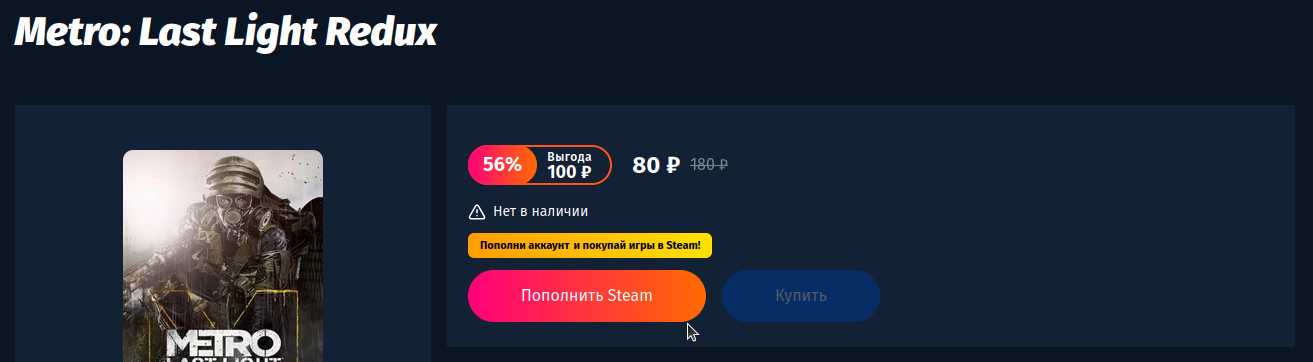
